Воробьев Андрей
Шакина Анна 396675

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from scipy.optimize import brentq

np.random.seed(627)

# Задание 1


## Постановка

Пусть дана выборка $X_1, \ldots, X_n \sim \text{Pois}(\theta)$, и требуется оценить параметр $\theta > 0$.

Априорное распределение (prior): $\theta \sim \Gamma(k, \lambda)$ с $k = \lambda = 1$, что совпадает с $\text{Exp}(1)$.

Плотность гамма-распределения:
$$\pi(\theta) = \frac{\lambda^k}{\Gamma(k)} \theta^{k-1} e^{-\lambda \theta}, \quad \theta > 0$$


In [2]:
TRUE_THETA = 3.0
K_PRIOR = 1
LAMBDA_PRIOR = 1
N_REPEAT = 5_000
SAMPLE_SIZES = [5, 10, 20, 50, 100, 500]
CREDIBLE_LEVEL = 0.95



## 1. Оценка максимального правдоподобия (ОМП)

Функция правдоподобия для Пуассоновской выборки:
$$L(X_1, \ldots, X_n \mid \theta) = \prod_{i=1}^n \frac{\theta^{X_i} e^{-\theta}}{X_i!} = \frac{\theta^{S_n} e^{-n\theta}}{\prod_{i=1}^n X_i!}, \quad S_n = \sum_{i=1}^n X_i$$

Логарифм правдоподобия:
$$\ln L = S_n \ln \theta - n\theta - \text{const}$$

Берём производную и приравниваем к нулю:
$$\frac{d \ln L}{d\theta} = \frac{S_n}{\theta} - n = 0 \implies \hat{\theta}_{\text{MLE}} = \frac{S_n}{n} = \bar{X}_n$$

### Теоретические характеристики ОМП

Так как $X_i \sim \text{Pois}(\theta)$, то $\mathbb{E}[X_i] = \theta$, $\text{Var}(X_i) = \theta$.

- **Смещение:** $\text{bias}(\hat{\theta}_{\text{MLE}}) = \mathbb{E}[\bar{X}_n] - \theta = \theta - \theta = 0$
- **Дисперсия:** $\text{Var}(\hat{\theta}_{\text{MLE}}) = \frac{\theta}{n}$
- **MSE:** $\text{MSE}(\hat{\theta}_{\text{MLE}}) = \text{bias}^2 + \text{Var} = \frac{\theta}{n}$


## 2. Байесовская оценка

### Апостериорное распределение

По теореме Байеса:
$$\pi(\theta \mid X_1, \ldots, X_n) \propto L(X_1, \ldots, X_n \mid \theta) \cdot \pi(\theta)$$
$$\propto \theta^{S_n} e^{-n\theta} \cdot \theta^{k-1} e^{-\lambda\theta} = \theta^{S_n + k - 1} e^{-(n + \lambda)\theta}$$

Это ядро гамма-распределения:
$$(\theta \mid X_1, \ldots, X_n) \sim \Gamma\!\left(k + S_n,\; \lambda + n\right)$$

### Байесовская оценка (квадратичная функция потерь)

Из лекционного материала: при квадратичной функции потерь байесовская оценка есть
$$\hat{\theta}_B = \mathbb{E}[\theta \mid X_1, \ldots, X_n]$$

Математическое ожидание $\Gamma(\alpha, \beta)$ равно $\frac{\alpha}{\beta}$, поэтому:
$$\hat{\theta}_B = \frac{k + S_n}{\lambda + n} = \frac{\lambda}{\lambda + n} \cdot \frac{k}{\lambda} + \frac{n}{\lambda + n} \cdot \bar{X}_n$$

При $k = \lambda = 1$:
$$\hat{\theta}_B = \frac{1 + S_n}{1 + n}$$

Это взвешенное среднее априорного среднего ($k/\lambda = 1$) и ОМП.

### Теоретические характеристики байесовской оценки

Обозначим $\alpha^* = k + S_n = 1 + S_n$, $\beta^* = \lambda + n = 1 + n$.

Т.к. $S_n \sim \text{Pois}(n\theta)$, имеем $\mathbb{E}[S_n] = n\theta$, $\text{Var}(S_n) = n\theta$.

- **Смещение:**
$$\text{bias}(\hat{\theta}_B) = \mathbb{E}\!\left[\frac{1 + S_n}{1 + n}\right] - \theta = \frac{1 + n\theta}{1 + n} - \theta = \frac{1 - \theta}{1 + n}$$

- **Дисперсия:**
$$\text{Var}(\hat{\theta}_B) = \frac{\text{Var}(S_n)}{(1+n)^2} = \frac{n\theta}{(1+n)^2}$$

- **MSE:**
$$\text{MSE}(\hat{\theta}_B) = \left(\frac{1-\theta}{1+n}\right)^2 + \frac{n\theta}{(1+n)^2} = \frac{(1-\theta)^2 + n\theta}{(1+n)^2}$$


## 3. Credible Interval

Апостериорное распределение $\Gamma(1 + S_n,\; 1 + n)$.

### Equal-tailed (ET)
$$\theta_l = F_{\Gamma}^{-1}\!\left(\frac{1-\gamma}{2}\right), \quad \theta_r = F_{\Gamma}^{-1}\!\left(\frac{1+\gamma}{2}\right)$$

### Highest Posterior Density (HPD)
Ищем кратчайший интервал $(\theta_l, \theta_r)$ такой, что
$$\int_{\theta_l}^{\theta_r} \pi(\theta \mid X) \, d\theta \geq \gamma$$
При унимодальном распределении это интервал, на котором плотность не опускается ниже некоторого уровня $c^*$.

## Теоретические формулы

In [3]:
def theoretical_mle(theta, n):
    bias = 0.0
    var  = theta / n
    mse  = var
    return bias, var, mse

In [4]:
def theoretical_bayes(theta, n, k=K_PRIOR, lam=LAMBDA_PRIOR):
    beta_star = lam + n
    bias = (k/lam - theta) * lam / beta_star
    var  = n * theta / beta_star**2
    mse  = bias**2 + var
    return bias, var, mse

## Вычисление оценок

In [5]:
def mle(sample):
    return np.mean(sample)

In [6]:
def bayes_estimate(sample, k=K_PRIOR, lam=LAMBDA_PRIOR):
    return (k + np.sum(sample)) / (lam + len(sample))

## Credible interval

In [7]:
def posterior_params(sample, k=K_PRIOR, lam=LAMBDA_PRIOR):
    alpha_post = k + np.sum(sample)
    beta_post  = lam + len(sample)
    return alpha_post, beta_post

In [8]:
def credible_equal_tailed(sample, level=CREDIBLE_LEVEL):
    alpha, beta = posterior_params(sample)
    dist = stats.gamma(a=alpha, scale=1.0/beta)
    lo = dist.ppf((1 - level) / 2)
    hi = dist.ppf((1 + level) / 2)
    return lo, hi

In [9]:
def credible_hpd(sample, level=CREDIBLE_LEVEL, n_grid=10_000):
    alpha, beta = posterior_params(sample)
    dist = stats.gamma(a=alpha, scale=1.0/beta)

    mode = max((alpha - 1) / beta, 0.0)

    if alpha <= 1:
        return 0.0, dist.ppf(level)

    def coverage(c):
        log_c = np.log(c)
        def log_dens(x):
            return dist.logpdf(x)
        try:
            tl = brentq(lambda x: log_dens(x) - log_c,
                        dist.ppf(1e-9), mode - 1e-12)
        except ValueError:
            tl = dist.ppf(1e-9)
        try:
            tr = brentq(lambda x: log_dens(x) - log_c,
                        mode + 1e-12, dist.ppf(1 - 1e-9))
        except ValueError:
            tr = dist.ppf(1 - 1e-9)
        return dist.cdf(tr) - dist.cdf(tl), tl, tr

    c_lo, c_hi = 0.0, dist.pdf(mode)
    for _ in range(60):
        c_mid = (c_lo + c_hi) / 2
        cov, tl, tr = coverage(c_mid)
        if cov > level:
            c_lo = c_mid
        else:
            c_hi = c_mid
    _, tl, tr = coverage((c_lo + c_hi) / 2)
    return tl, tr

## Эксперимент


In [10]:
results = {}
for n in SAMPLE_SIZES:
    mle_vals = []
    bayes_vals = []
    for _ in range(N_REPEAT):
        sample = np.random.poisson(TRUE_THETA, size=n)
        mle_vals.append(np.mean(sample))
        bayes_vals.append((K_PRIOR + np.sum(sample)) / (LAMBDA_PRIOR + n))

    mle_vals = np.array(mle_vals)
    bayes_vals = np.array(bayes_vals)

    results[n] = {
        "mle_bias_emp": np.mean(mle_vals) - TRUE_THETA,
        "mle_var_emp": np.var(mle_vals, ddof=1),
        "mle_mse_emp": np.mean((mle_vals - TRUE_THETA)**2),
        "bayes_bias_emp": np.mean(bayes_vals) - TRUE_THETA,
        "bayes_var_emp": np.var(bayes_vals, ddof=1),
        "bayes_mse_emp": np.mean((bayes_vals - TRUE_THETA)**2),
        "mle_bias_th": 0.0,
        "mle_var_th": TRUE_THETA / n,
        "mle_mse_th": TRUE_THETA / n,
        "bayes_bias_th": (1 - TRUE_THETA) / (1 + n),
        "bayes_var_th": n * TRUE_THETA / (1 + n)**2,
        "bayes_mse_th": (1 - TRUE_THETA)**2 / (1 + n)**2 + n * TRUE_THETA / (1 + n)**2,
    }

## Визуализация

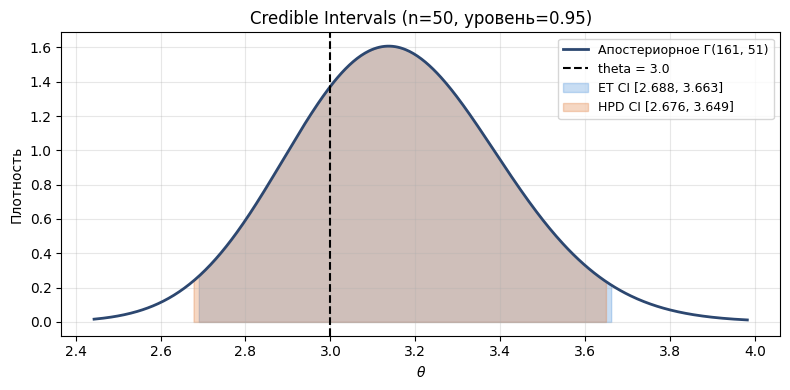

[Credible Intervals | n=50]
Equal-tailed:[2.6881, 3.6628]  width=0.9747
HPD: [2.6757, 3.6491] width=0.9734


In [11]:
n_demo = 50
sample = np.random.poisson(TRUE_THETA, size=n_demo)

alpha_post = K_PRIOR + np.sum(sample)
beta_post  = LAMBDA_PRIOR + n_demo
post = stats.gamma(a=alpha_post, scale=1.0 / beta_post)

et_lo = post.ppf((1 - CREDIBLE_LEVEL) / 2)
et_hi = post.ppf((1 + CREDIBLE_LEVEL) / 2)
hpd_lo, hpd_hi = credible_hpd(sample)

x = np.linspace(post.ppf(0.001), post.ppf(0.999), 500)
pdf = post.pdf(x)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(x, pdf, color="#2c4770", lw=2, label=f"Апостериорное Г({alpha_post}, {beta_post})")
ax.axvline(TRUE_THETA, color="black", ls="--", label=f"theta = {TRUE_THETA}")
ax.fill_between(x, pdf, where=(x >= et_lo)  & (x <= et_hi),
                alpha=0.30, color="#4a90d9", label=f"ET CI [{et_lo:.3f}, {et_hi:.3f}]")
ax.fill_between(x, pdf, where=(x >= hpd_lo) & (x <= hpd_hi),
                alpha=0.30, color="#e07b39", label=f"HPD CI [{hpd_lo:.3f}, {hpd_hi:.3f}]")

ax.set_xlabel(r"$\theta$")
ax.set_ylabel("Плотность")
ax.set_title(f"Credible Intervals (n={n_demo}, уровень={CREDIBLE_LEVEL})")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"[Credible Intervals | n={n_demo}]")
print(f"Equal-tailed:[{et_lo:.4f}, {et_hi:.4f}]  width={et_hi - et_lo:.4f}")
print(f"HPD: [{hpd_lo:.4f}, {hpd_hi:.4f}] width={hpd_hi - hpd_lo:.4f}")

## Таблица результатов

In [12]:
print(f"theta = {TRUE_THETA},  prior = Г(k={K_PRIOR}, lambda={LAMBDA_PRIOR})")
print(f"{'n':>6} | {'Оценка':>8} | {'bias th':>10} {'bias emp':>10} | "
      f"{'var th':>10} {'var emp':>10} | {'MSE th':>10} {'MSE emp':>10}")
print("-" * 100)
for n, r in results.items():
    for est, label in [("mle", "ОМП"), ("bayes", "Байес")]:
        print(f"{n:>6} | {label:>8} | "
              f"{r[f'{est}_bias_th']:>10.5f} {r[f'{est}_bias_emp']:>10.5f} | "
              f"{r[f'{est}_var_th']:>10.5f} {r[f'{est}_var_emp']:>10.5f} | "
              f"{r[f'{est}_mse_th']:>10.5f} {r[f'{est}_mse_emp']:>10.5f}")
    print()

theta = 3.0,  prior = Г(k=1, lambda=1)
     n |   Оценка |    bias th   bias emp |     var th    var emp |     MSE th    MSE emp
----------------------------------------------------------------------------------------------------
     5 |      ОМП |    0.00000   -0.00008 |    0.60000    0.59007 |    0.60000    0.58995
     5 |    Байес |   -0.33333   -0.33340 |    0.41667    0.40977 |    0.52778    0.52084

    10 |      ОМП |    0.00000   -0.00138 |    0.30000    0.29394 |    0.30000    0.29388
    10 |    Байес |   -0.18182   -0.18307 |    0.24793    0.24292 |    0.28099    0.27639

    20 |      ОМП |    0.00000    0.00107 |    0.15000    0.15292 |    0.15000    0.15289
    20 |    Байес |   -0.09524   -0.09422 |    0.13605    0.13870 |    0.14512    0.14755

    50 |      ОМП |    0.00000   -0.00253 |    0.06000    0.05820 |    0.06000    0.05820
    50 |    Байес |   -0.03922   -0.04170 |    0.05767    0.05594 |    0.05921    0.05767

   100 |      ОМП |    0.00000   -0.00099 |   

## Графики

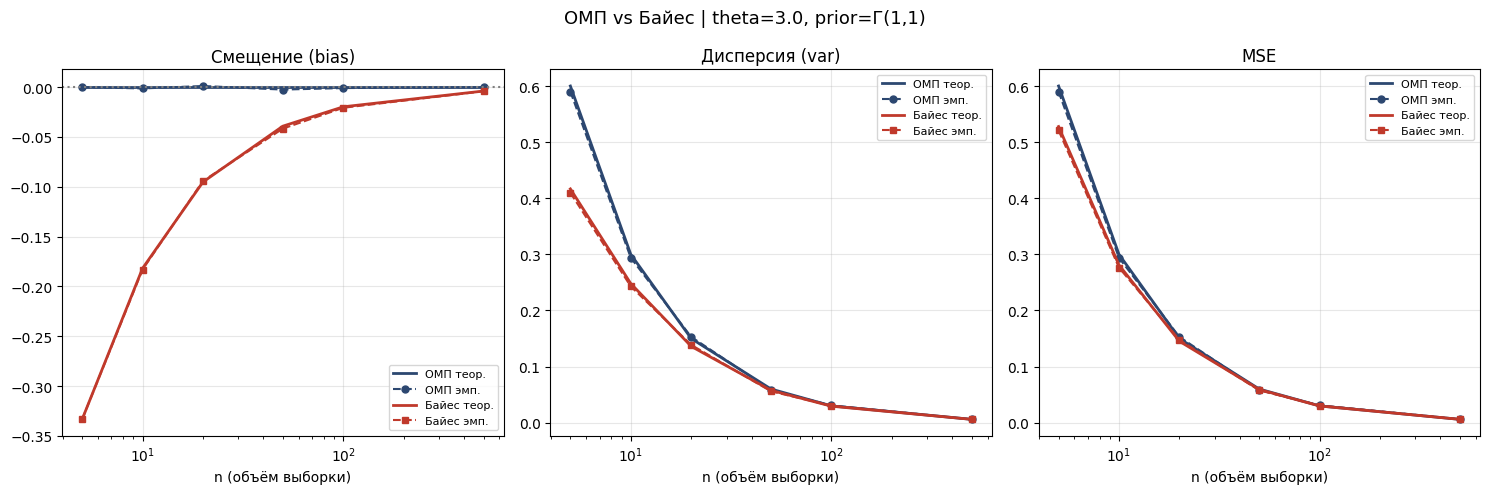

In [13]:
ns = list(results.keys())
metrics = ["bias", "var", "mse"]
titles  = ["Смещение (bias)", "Дисперсия (var)", "MSE"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, title in zip(axes, metrics, titles):
    mle_th = [results[n][f"mle_{metric}_th"] for n in ns]
    mle_emp = [results[n][f"mle_{metric}_emp"] for n in ns]
    b_th = [results[n][f"bayes_{metric}_th"] for n in ns]
    b_emp = [results[n][f"bayes_{metric}_emp"] for n in ns]

    ax.plot(ns, mle_th, color="#2c4770", lw=2, ls="-", label="ОМП теор.")
    ax.plot(ns, mle_emp, color="#2c4770", lw=1.5, ls="--", marker="o", ms=5, label="ОМП эмп.")
    ax.plot(ns, b_th, color="#c0392b", lw=2, ls="-",  label="Байес теор.")
    ax.plot(ns, b_emp, color="#c0392b", lw=1.5, ls="--", marker="s", ms=5, label="Байес эмп.")

    ax.set_xscale("log")
    ax.set_xlabel("n (объём выборки)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    if metric == "bias":
        ax.axhline(0, color="grey", ls=":")

fig.suptitle(f"ОМП vs Байес | theta={TRUE_THETA}, prior=Г({K_PRIOR},{LAMBDA_PRIOR})", fontsize=13)
plt.tight_layout()
plt.show()

# Задание 2

In [14]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: C:\Users\Professional\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [15]:
from ucimlrepo import fetch_ucirepo

soybean_large = fetch_ucirepo(id=90)

X = soybean_large.data.features
y = soybean_large.data.targets

print(soybean_large.metadata)
print(soybean_large.variables)

{'uci_id': 90, 'name': 'Soybean (Large)', 'repository_url': 'https://archive.ics.uci.edu/dataset/90/soybean+large', 'data_url': 'https://archive.ics.uci.edu/static/public/90/data.csv', 'abstract': "Michalski's famous soybean disease database", 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 307, 'num_features': 35, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1980, 'last_updated': 'Sun Feb 11 2024', 'dataset_doi': '10.24432/C5JG6Z', 'creators': ['R.S. Michalski', 'R.L. Chilausky'], 'intro_paper': None, 'additional_info': {'summary': 'There are 19 classes, only the first 15 of which have been used in prior work. The folklore seems to be that the last four classes are unjustified by the data since they have so few examples. There are 35 categorical attributes, some nominal and some ordered.  The

## Условие

Датасет: **Soybean (Large)**

Целевая переменная: `class` - тип болезни сои (19 классов).

Признаки: 35 категориальных атрибутов.


## Шаг 1. Выбор независимых атрибутов (хи-квадрат тест)

Для проверки зависимости категориального признака $F_j$ от целевой переменной $C$
используем критерий независимости хи-квадрат.

**Нулевая гипотеза** $H_0$: признак $F_j$ независим от $C$.

Статистика:

$$\chi^2 = \sum_{i,j} \frac{(\nu_{i,j} - n \cdot \hat{p}_{X,i} \cdot \hat{p}_{Y,j})^2}{n \cdot \hat{p}_{X,i} \cdot \hat{p}_{Y,j}}$$

где $\nu_{i,j}$ -- количество пар с $X=i, Y=j$, а $\hat{p}_{X,i} = \nu_{i,*}/n$,
$\hat{p}_{Y,j} = \nu_{*,j}/n$ -- оценки МП маргинальных вероятностей.

При истинности $H_0$ предельное распределение статистики -
$\chi^2$ с $(k-1)(l-1)$ степенями свободы.

Отбираем признаки, для которых p-value $< 0.05$
(т.е. $H_0$ отвергается -- признак зависим от класса).


In [16]:
print("Размер датасета:", X.shape)
print("\nРаспределение классов:")
print(y['class'].value_counts())
print("\nДоля пропусков по признакам (%):")
print((X.isnull().mean() * 100).round(1).sort_values(ascending=False).head(20))

Размер датасета: (307, 35)

Распределение классов:
class
phytophthora-rot               40
brown-spot                     40
alternarialeaf-spot            40
frog-eye-leaf-spot             40
brown-stem-rot                 20
anthracnose                    20
diaporthe-stem-canker          10
charcoal-rot                   10
rhizoctonia-root-rot           10
powdery-mildew                 10
downy-mildew                   10
bacterial-blight               10
bacterial-pustule              10
purple-seed-stain              10
phyllosticta-leaf-spot         10
diaporthe-pod-&-stem-blight     6
cyst-nematode                   6
herbicide-injury                4
2-4-d-injury                    1
Name: count, dtype: int64

Доля пропусков по признакам (%):
seed-tmt           13.4
severity           13.4
hail               13.4
lodging            13.4
germination        11.7
fruiting-bodies    11.4
fruit-spots        11.4
shriveling         11.4
seed-discolor      11.4
leaf-mild           9

В условии к датасету указано, что последние 4 класса отбрасываются из-за малого количества примеров, поэтому мы будем работать только с 15 классами.

In [17]:
valid_classes = y['class'].value_counts().index[:15]
mask = y['class'].isin(valid_classes)
X = X[mask]
y = y[mask]

Пропуски в данных могут влиять на результаты теста, поэтому заполним их специальной категорией "missing" перед построением таблицы сопряжённости.

In [18]:
df = X.copy()
df['class'] = y['class'].values

df_filled = df.fillna('missing')

results = []
for col in X.columns:
    contingency = pd.crosstab(df_filled[col], df_filled['class'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    results.append({'feature': col, 'chi2': chi2, 'p_value': p, 'dof': dof})

results_df = pd.DataFrame(results).sort_values('p_value')

print("Результаты chi2-теста (все признаки):")
print(results_df.to_string(index=False))

significant = results_df[results_df['p_value'] < 0.05]['feature'].tolist()
print(f"\nОтобрано признаков с p < 0.05: {len(significant)}")
print(significant)

Результаты chi2-теста (все признаки):
        feature       chi2       p_value  dof
    fruit-spots 733.939212 7.383192e-119   56
      leaf-mild 664.348249 6.407409e-113   42
   int-discolor 580.000000 1.955866e-104   28
  leafspot-size 597.028037  3.163628e-99   42
 leafspots-marg 594.419444  1.068404e-98   42
  canker-lesion 549.705702  1.152078e-89   42
     fruit-pods 539.120189  1.555493e-87   42
 leafspots-halo 512.584751  3.291216e-82   42
   stem-cankers 457.655182  2.917471e-71   42
           seed 361.734526  1.081288e-59   28
    mold-growth 358.343734  5.216565e-59   28
      sclerotia 290.000000  1.433494e-53   14
  seed-discolor 322.897820  6.761002e-52   28
       severity 352.177073  1.277103e-50   42
fruiting-bodies 311.523838  1.255309e-49   28
         precip 296.123655  1.440958e-46   28
      seed-size 280.290969  1.944341e-43   28
     shriveling 274.588086  2.582194e-42   28
   plant-growth 213.883657  7.909209e-38   14
           stem 208.028248  1.253140e-36  

Тест показывает, что 34 из 35 признаков статистически зависимы от класса, поэтому мы будем использовать все 34 признака для обучения модели.



## Шаг 2. Разбиение на подклассы $C_k$

Делим отобранные признаки на два подкласса:

- **$C_1$** - признаки, описывающие **состояние растения**
  (листья, стебель, корни, плоды, семена и т.п.)
- **$C_2$** - признаки, описывающие **внешние условия**
  (погода, история посева, повреждения и т.п.)

На каждом подклассе $C_k$ обучаем отдельный наивный байесовский классификатор.


In [19]:
C1 = [
    'leaves', 'leaf-mild', 'leaf-malf', 'leaf-shread',
    'leafspots-halo', 'leafspots-marg', 'leafspot-size',
    'stem', 'stem-cankers', 'canker-lesion',
    'plant-growth', 'lodging',
    'fruiting-bodies', 'fruit-pods', 'fruit-spots',
    'seed', 'seed-tmt', 'seed-discolor', 'seed-size', 'shriveling',
    'mold-growth', 'mycelium', 'sclerotia',
    'int-discolor', 'external-decay',
    'roots'
]
C2 = [
    'date', 'plant-stand', 'precip', 'temp',
    'hail', 'crop-hist', 'area-damaged',
    'severity', 'germination'
]

print(f"C1 (симптомы растения): {len(C1)} признаков")
print(C1)
print(f"\nC2 (внешние условия):   {len(C2)} признаков")
print(C2)
print(f"\nПересечение: {set(C1) & set(C2)}")

C1 (симптомы растения): 26 признаков
['leaves', 'leaf-mild', 'leaf-malf', 'leaf-shread', 'leafspots-halo', 'leafspots-marg', 'leafspot-size', 'stem', 'stem-cankers', 'canker-lesion', 'plant-growth', 'lodging', 'fruiting-bodies', 'fruit-pods', 'fruit-spots', 'seed', 'seed-tmt', 'seed-discolor', 'seed-size', 'shriveling', 'mold-growth', 'mycelium', 'sclerotia', 'int-discolor', 'external-decay', 'roots']

C2 (внешние условия):   9 признаков
['date', 'plant-stand', 'precip', 'temp', 'hail', 'crop-hist', 'area-damaged', 'severity', 'germination']

Пересечение: set()



## Шаг 3. Наивный байесовский классификатор

$$P(C \mid F_1, \ldots, F_m) \propto P(C) \cdot \prod_{j=1}^{m} P(F_j \mid C)$$

**Предположение наивности**: признаки $F_j$ независимы при условии $C$.

Классификатор выбирает:

$$\hat{C} = \arg\max_{C} \; P(C) \cdot \prod_{j=1}^{m} P(F_j \mid C)$$

Вероятности оцениваются по частотам на обучающей выборке.
Чтобы избежать нулевых вероятностей при редких значениях признака --
используем **сглаживание Лапласа**:

$$\hat{P}(F_j = v \mid C = c) = \frac{N(F_j=v,\; C=c) + 1}{N(C=c) + |\text{val}(F_j)|}$$

где $|\text{val}(F_j)|$ -- количество уникальных значений признака $F_j$.

На тестовой выборке считаем **accuracy**:

$$\text{accuracy} = \frac{1}{n_{\text{test}}} \sum_{i=1}^{n_{\text{test}}} \mathbf{1}[\hat{C}_i = C_i]$$